# EDA Notebook

## 1. Importar librerías necesarias
Configuramos el entorno e importamos pandas, numpy, matplotlib y seaborn para el análisis y visualización de datos.

In [58]:
import sys
from pathlib import Path

# Añadir carpeta raíz del proyecto al path
ROOT = Path().resolve().parent
sys.path.append(str(ROOT))

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import TRAIN_PATH, TEST_PATH
from src.io import load_data
from src.cleaning import clean_data
from src.features import build_features

sns.set(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)

## 2. Objetivos

Queremos analizar la satisfacción de los pasajeros de aerolíneas
e identificar los factores que influyen en la experiencia
del cliente.

Preguntas principales:
- ¿Influye la clase del vuelo en la satisfacción?
- ¿Afectan los retrasos a la experiencia del pasajero?
- ¿Qué servicios reciben mejores valoraciones?
- ¿Los clientes leales están más satisfechos?

## 3. Cargar el archivo CSV
Solicitar al usuario la ruta del archivo .csv y cargarlo en un DataFrame de pandas.

In [60]:
def load_and_merge(train_path="../data/raw/train.csv",
                   test_path="../data/raw/test.csv"):

    train = pd.read_csv(train_path, index_col=0)
    test = pd.read_csv(test_path, index_col=0)

    df = pd.concat([train, test], axis=0)
    return df

df = load_and_merge()


## 4. Visualizar las primeras filas del dataset
Mostrar las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [61]:
df.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 5. Explorar información general del dataset
Utilizar info() y shape para mostrar información sobre el número de filas, columnas y tipos de datos.

In [62]:
print("Shape:", df.shape)

print("\nTipos de datos:")
display(df.dtypes)

print("\nValores nulos:")
display(df.isna().sum())

print("\nDuplicados:", df.duplicated().sum())

print("\nDescripción numérica:")
display(df.describe())

print("\nDescripción categórica:")
display(df.describe(include=["str"]))

Shape: (129880, 24)

Tipos de datos:


id                                     int64
Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            int64
Departure Delay in Minutes             int64
Arrival De


Valores nulos:


id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             393
satisfaction                           0
dtype: int64


Duplicados: 0

Descripción numérica:


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,64940.500000,39.427957,1190.316392,2.728696,3.057599,2.756876,2.976925,3.204774,3.252633,3.441361,3.358077,3.383023,3.350878,3.632114,3.306267,3.642193,3.286326,14.713713,15.091129
std,37493.270818,15.119360,997.452477,1.329340,1.526741,1.401740,1.278520,1.329933,1.350719,1.319289,1.334049,1.287099,1.316252,1.180025,1.266185,1.176669,1.313682,38.071126,38.465650
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32470.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64940.500000,40.000000,844.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97410.250000,51.000000,1744.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000



Descripción categórica:


,Gender,Customer Type,Type of Travel,Class,satisfaction
count,129880,129880,129880,129880,129880
unique,2,2,2,3,2
top,Female,Loyal Customer,Business travel,Business,neutral or dissatisfied
freq,65899,106100,89693,62160,73452


## 5. Limpieza de dataset

In [63]:
# Normalizar columnas
df.columns = (
    df.columns
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

# Eliminar duplicados
df.drop_duplicates(inplace=True)

# Imputación de nulos
df["arrival_delay_in_minutes"] = df["arrival_delay_in_minutes"].fillna(
    df["arrival_delay_in_minutes"].median()
)

# Convertir a categorías
cat_cols = ["gender", "customer_type", "type_of_travel", "class", "satisfaction"]
for col in cat_cols:
    df[col] = df[col].astype("category")

## 6. Variables numéricas y categóricas

In [64]:

print("===== Variables numéricas =====")


print(df.describe(include="number"))

print("===== Variables categóricas =====")
categorical_cols = (
    df.select_dtypes(include="object")
    .columns
)

for col in categorical_cols:

    print(f"\n===== {col} =====")

    print(df[col].value_counts())

===== Variables numéricas =====
                  id            age  flight_distance  inflight_wifi_service  \
count  129880.000000  129880.000000    129880.000000          129880.000000   
mean    64940.500000      39.427957      1190.316392               2.728696   
std     37493.270818      15.119360       997.452477               1.329340   
min         1.000000       7.000000        31.000000               0.000000   
25%     32470.750000      27.000000       414.000000               2.000000   
50%     64940.500000      40.000000       844.000000               3.000000   
75%     97410.250000      51.000000      1744.000000               4.000000   
max    129880.000000      85.000000      4983.000000               5.000000   

       departure/arrival_time_convenient  ease_of_online_booking  \
count                      129880.000000           129880.000000   
mean                            3.057599                2.756876   
std                             1.526741            

## 7. Feature engineering

In [65]:
df["total_delay"] = (
    df["departure_delay_in_minutes"].clip(lower=0) +
    df["arrival_delay_in_minutes"].clip(lower=0)
)

df["is_premium_customer"] = np.where(
    (df["customer_type"].str.title() == "Loyal Customer") &
    (df["class"].str.title().isin(["Business", "Eco Plus"])),
    1, 0
)

df["age_group"] = pd.cut(
    df["age"].clip(lower=0, upper=100),
    bins=[0, 18, 30, 45, 60, 120],
    labels=["Teen", "Young Adult", "Adult", "Mature", "Senior"],
    include_lowest=True
)

In [66]:
# Mostrar nombres de columnas
df.columns

Index(['id', 'gender', 'customer_type', 'age', 'type_of_travel', 'class',
       'flight_distance', 'inflight_wifi_service',
       'departure/arrival_time_convenient', 'ease_of_online_booking',
       'gate_location', 'food_and_drink', 'online_boarding', 'seat_comfort',
       'inflight_entertainment', 'on_board_service', 'leg_room_service',
       'baggage_handling', 'checkin_service', 'inflight_service',
       'cleanliness', 'departure_delay_in_minutes', 'arrival_delay_in_minutes',
       'satisfaction', 'total_delay', 'is_premium_customer', 'age_group'],
      dtype='str')

## 8. Tablas de evidencia cuantitativas

In [67]:
print("\n===== Distribución de satisfacción por clase =====")
display(df.groupby("class")["satisfaction"].value_counts(normalize=True).unstack().round(3))

print("\n===== Retraso medio por satisfacción =====")
display(df.groupby("satisfaction")["total_delay"].agg(["mean", "median", "std"]).round(2))

print("\n===== Servicios por satisfacción =====")
service_cols = [
    "seat_comfort", "inflight_entertainment", "cleanliness",
    "food_and_drink", "on_board_service", "baggage_handling",
    "checkin_service", "inflight_wifi_service"
]

display(df.groupby("satisfaction")[service_cols].mean().round(2))



===== Distribución de satisfacción por clase =====


satisfaction,neutral or dissatisfied,satisfied
class,,
Business,0.306,0.694
Eco,0.812,0.188
Eco Plus,0.754,0.246



===== Retraso medio por satisfacción =====


,mean,median,std
satisfaction,,,
neutral or dissatisfied,33.41,3.0,79.83
satisfied,25.01,1.0,69.69



===== Servicios por satisfacción =====


,seat_comfort,inflight_entertainment,cleanliness,food_and_drink,on_board_service,baggage_handling,checkin_service,inflight_wifi_service
satisfaction,,,,,,,,
neutral or dissatisfied,3.04,2.89,2.93,2.96,3.02,3.37,3.04,2.40
satisfied,3.97,3.96,3.75,3.53,3.86,3.97,3.65,3.16


## 10. Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

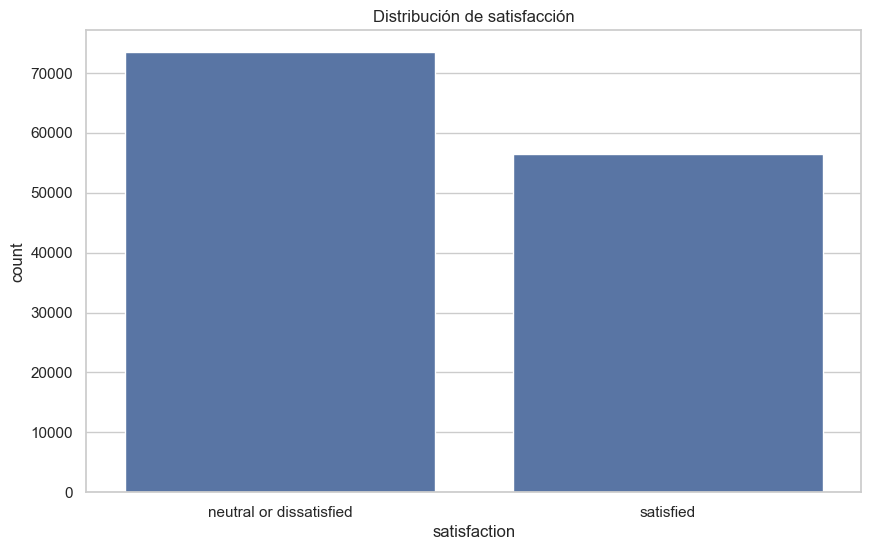

In [68]:
# Bar plot for a categorical variable
# Distribución de satisfacción 

sns.countplot(data=df, x="satisfaction")
plt.title("Distribución de satisfacción")
plt.show()

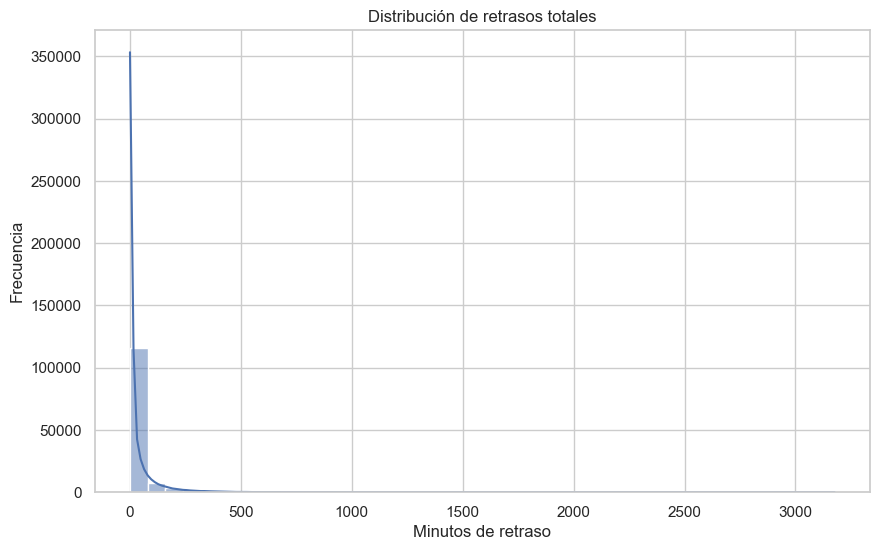

In [69]:
# Distribución del retraso total
sns.histplot(
    df["total_delay"],
    bins=40,
    kde=True
)

plt.title("Distribución de retrasos totales")

plt.xlabel("Minutos de retraso")

plt.ylabel("Frecuencia")

plt.show()

## 11. Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

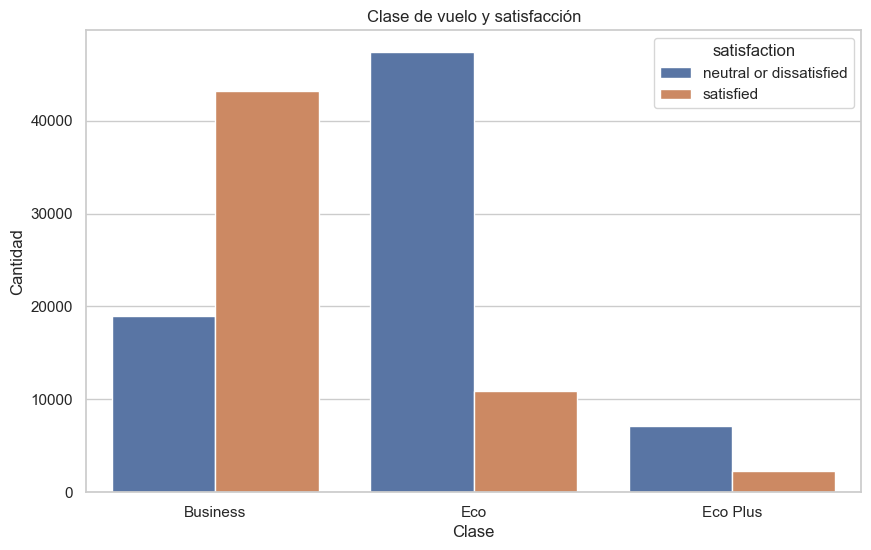

In [70]:
# Relación entre clase de vuelo y satisfacción
sns.countplot(
    data=df,
    x="class",
    hue="satisfaction"
)

plt.title("Clase de vuelo y satisfacción")

plt.xlabel("Clase")

plt.ylabel("Cantidad")

plt.show()

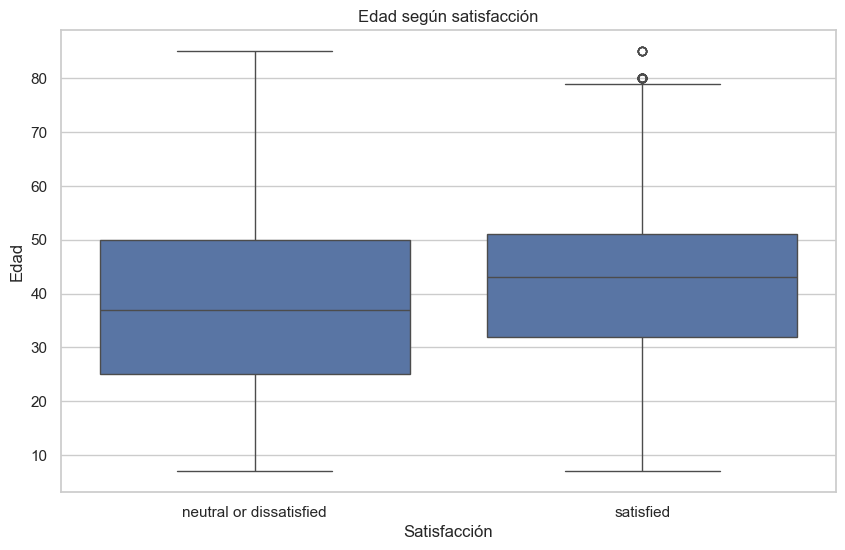

In [71]:
# Relación entre edad y satisfacción
sns.boxplot(
    data=df,
    x="satisfaction",
    y="age"
)

plt.title("Edad según satisfacción")

plt.xlabel("Satisfacción")

plt.ylabel("Edad")

plt.show()

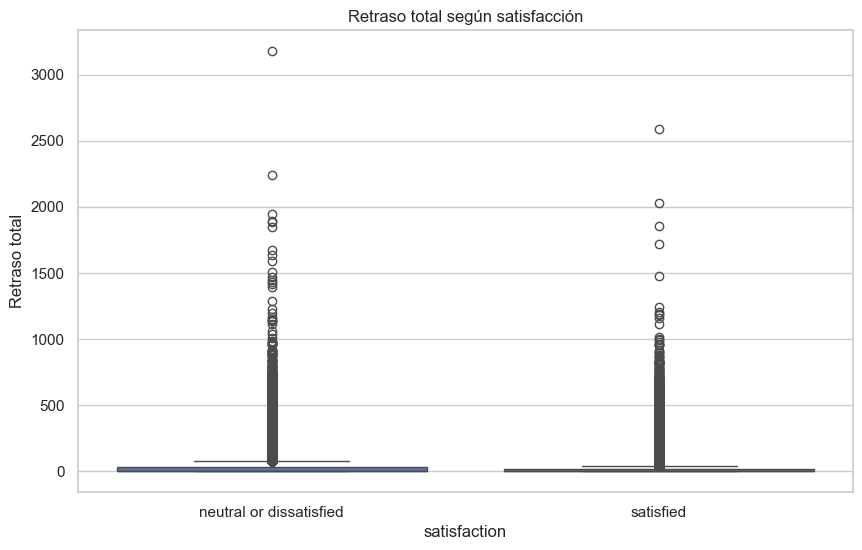

In [72]:
#Retraso total vs satisfacción
sns.boxplot(data=df, x="satisfaction", y="total_delay")
plt.title("Retraso total según satisfacción")
plt.ylabel("Retraso total")
plt.show()

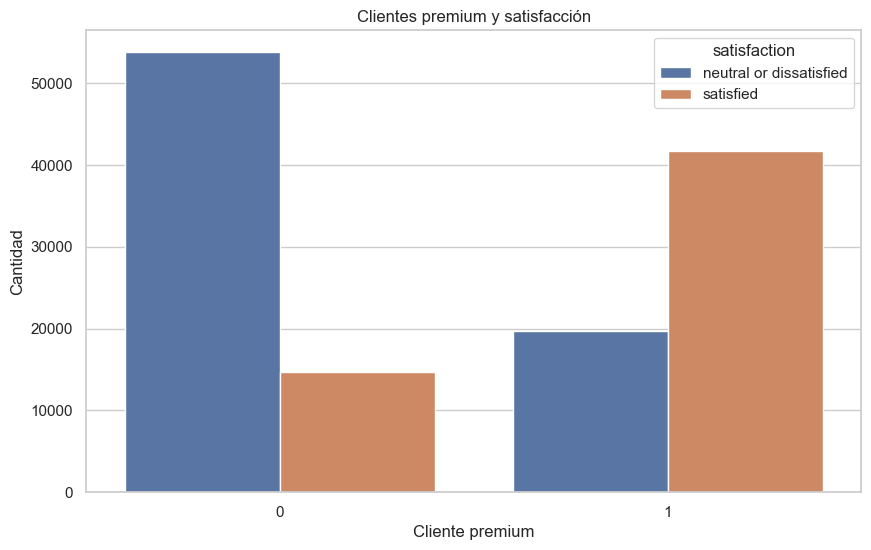

In [73]:
# Relación entre clientes premium y satisfacción
sns.countplot(
    data=df,
    x="is_premium_customer",
    hue="satisfaction"
)

plt.title("Clientes premium y satisfacción")

plt.xlabel("Cliente premium")

plt.ylabel("Cantidad")

plt.show()

## 12. Visualización de correlaciones
Calcular y visualizar la matriz de correlación entre variables numéricas usando un heatmap.

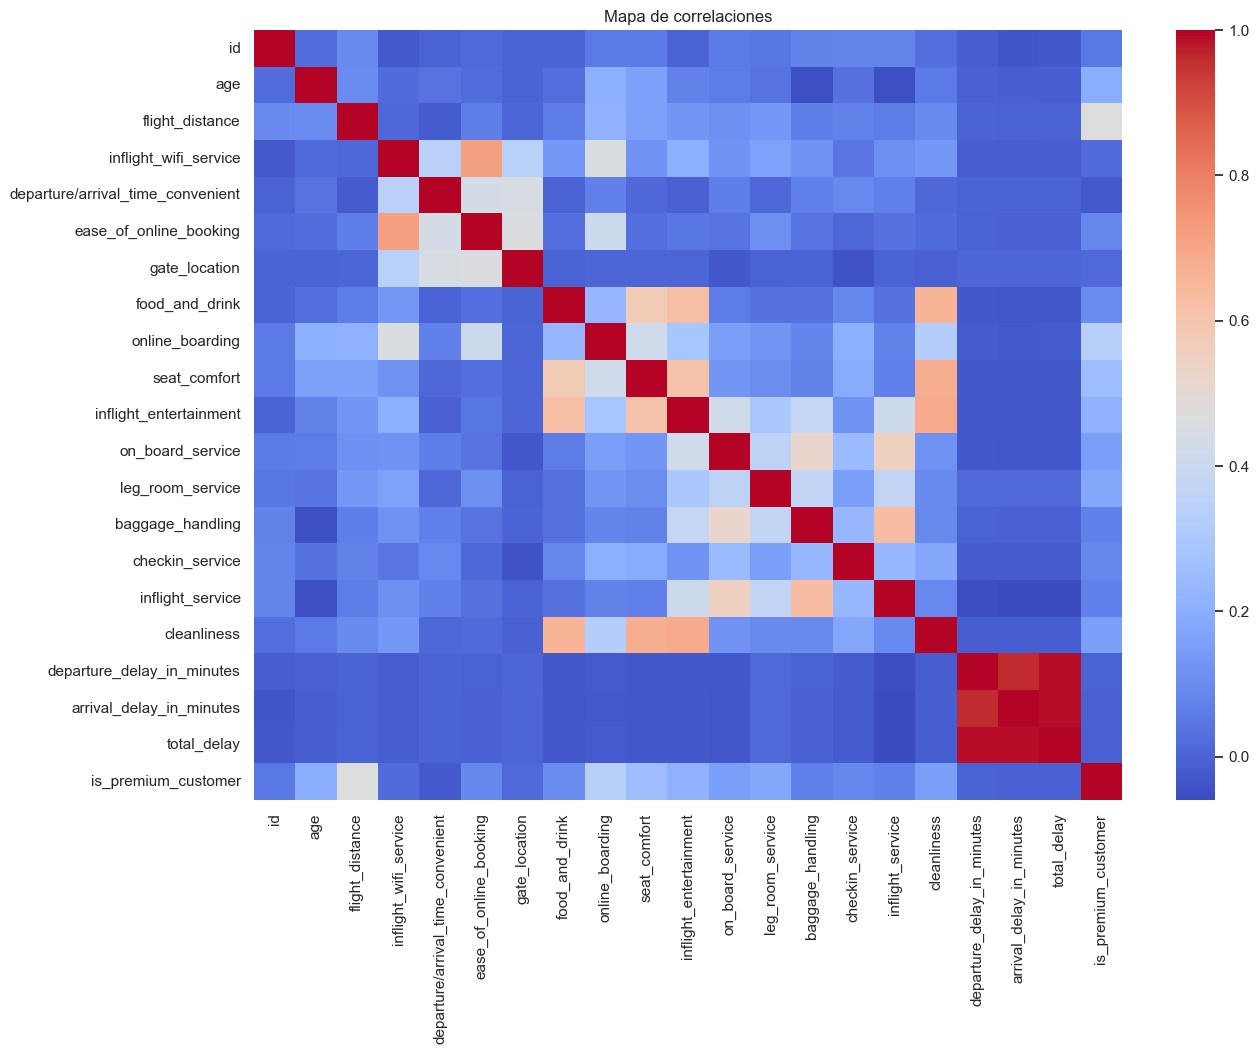

In [74]:
# Correlation matrix
# Seleccionar variables numéricas
numeric_df = df.select_dtypes(include=np.number)

# Calcular correlaciones
corr = numeric_df.corr()

# Crear heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Mapa de correlaciones")

plt.show()

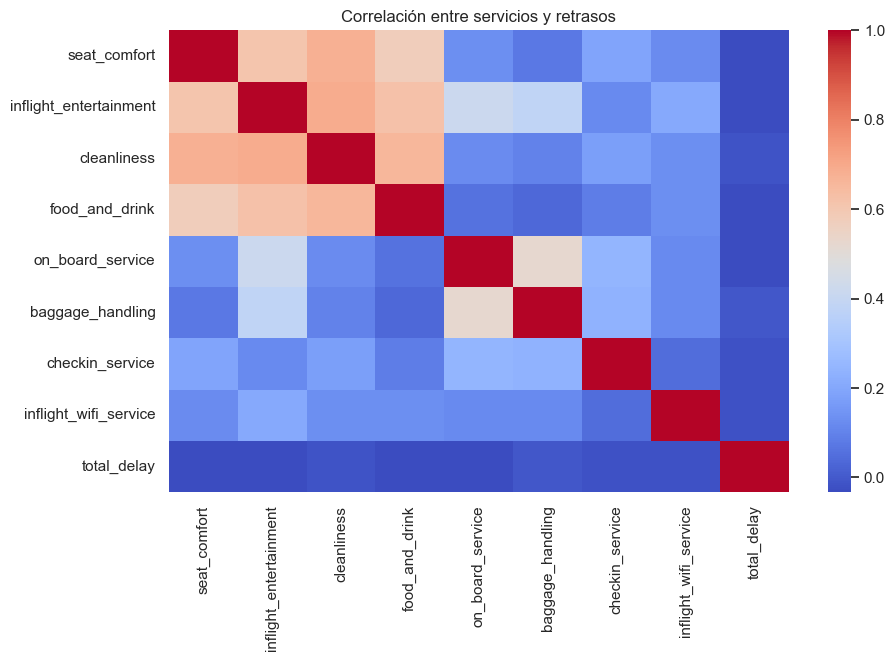

In [75]:
corr = df[service_cols + ["total_delay"]].corr()
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlación entre servicios y retrasos")
plt.show()

## 13. Valoración de servicios

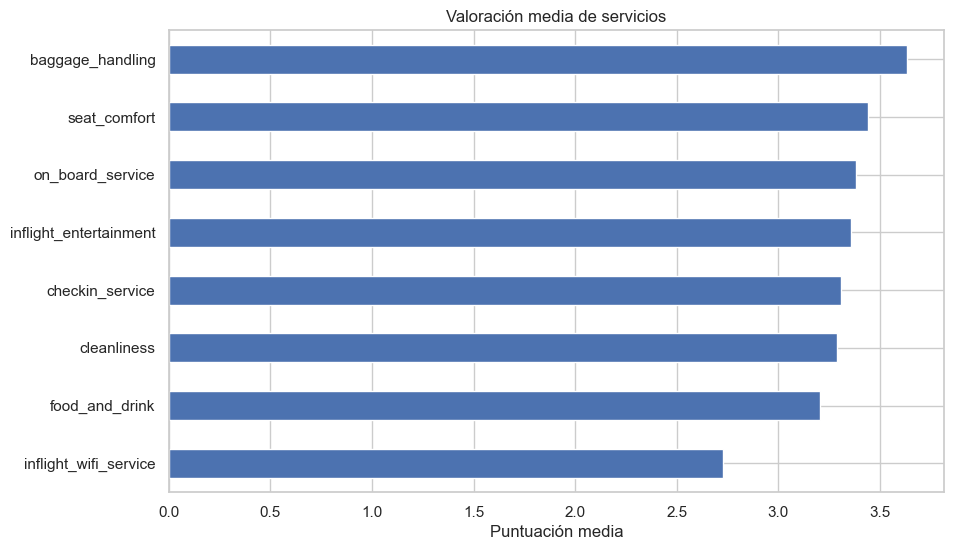

In [ ]:
# Variables de servicios
# Media de puntuaciones
service_means = (
    df[service_cols]
    .mean()
    .sort_values()
)
        
# Gráfico
service_means.plot(kind="barh")

plt.title("Valoración media de servicios")

plt.xlabel("Puntuación media")

plt.show()

## 14. Visualización multivariada

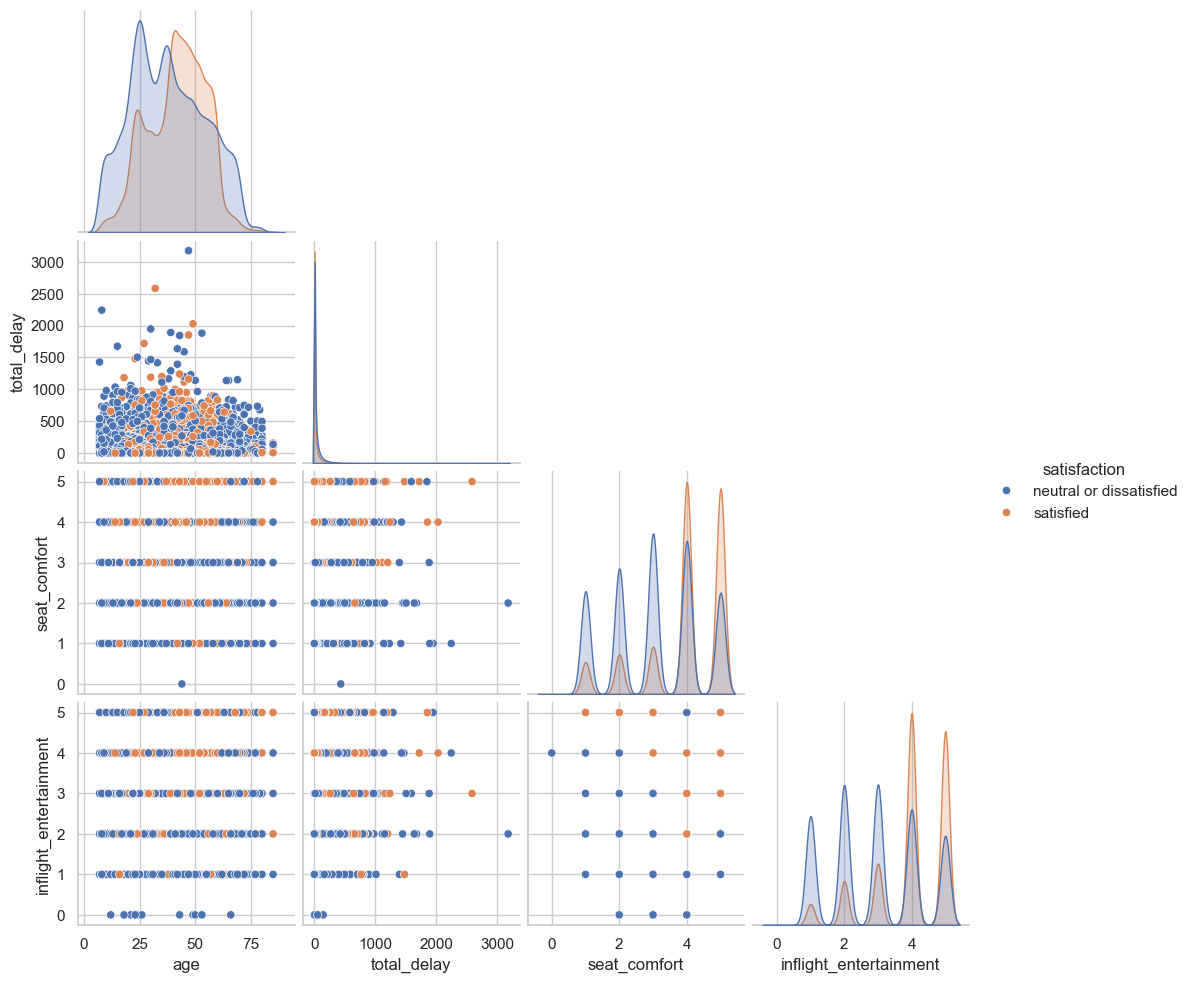

In [81]:
sns.pairplot(
    df,
    vars=["age", "total_delay", "seat_comfort", "inflight_entertainment"],
    hue="satisfaction",
    corner=True
)
plt.show()

In [ ]:
# Distancia media de vuelo por grupo de edad
df.groupby("age_group")["flight_distance"].mean()

age_group
Teen            927.605781
Young Adult    1038.742603
Adult          1253.894798
Mature         1379.588058
Senior          961.391387
Name: flight_distance, dtype: float64

## 15. Satisfacción por clase

In [ ]:
(df.groupby("class")["satisfaction"].value_counts(normalize=True)*100)

class     satisfaction           
Business  satisfied                  69.443372
          neutral or dissatisfied    30.556628
Eco       neutral or dissatisfied    81.232743
          satisfied                  18.767257
Eco Plus  neutral or dissatisfied    75.358623
          satisfied                  24.641377
Name: proportion, dtype: float64

## 16. Conclusiones
1. Los pasajeros de clase Business presentan mayores
niveles de satisfacción.

2. Los retrasos elevados están relacionados con
experiencias negativas.

3. Los clientes leales muestran una mayor satisfacción.

4. Los servicios mejor valorados son:
   - Seat comfort
   - Inflight entertainment
   - Cleanliness

5. Los pasajeros de clase Economy presentan menores
niveles de satisfacción general.

## 17.Exportamos el dataset limpio

In [ ]:
# Exportar dataset procesado
df.to_csv(
    "../data/processed/clean_airline_passenger_satisfaction.csv",
    index=False
)

print("Dataset exportado correctamente")

Dataset exportado correctamente


## Resumen del pipeline
PIPELINE DEL PROYECTO

1. Carga de datasets train y test
2. Unión de datasets
3. Limpieza de datos
4. Tratamiento de valores nulos
5. Creación de nuevas variables
6. Análisis exploratorio (EDA)
7. Generación de visualizaciones
8. Exportación del dataset limpio